# Sales Prediction — Final Evaluation & Model Persistence

**CodSoft Data Science Internship — Task 4: Sales Prediction Using Python**
(local folder `Task2_Sales_Prediction`, my own project numbering)

**Phase 5.** The model was selected in [Phase 4](04_model_validation_tuning.ipynb) using cross-validation on
the training set only. This notebook evaluates that locked model **once** on the 40-row test set that has
been reserved since Phase 2, then persists the fitted pipeline.

**The selection is closed before this notebook starts.** Nothing here chooses between models, tunes a
parameter, or changes a preprocessing decision.

---
## 1. Phase 5 Overview

### The rule being followed

A hold-out set is only a hold-out the first time it is used. Phase 4 therefore pre-registered both the model
and the rule for interpreting the result:

> Fit the selected configuration on all 160 training rows and evaluate it **once** on the 40-row test set.
> Report that number as the final result, without re-selecting afterwards. If the test score is worse than
> the CV estimate, that is information about a 40-row sample, not a reason to go back and pick the other
> model.

That rule is honoured below, and it turns out to matter — see section 8.

### The locked model

Phase 4 recommended the **tuned Gradient Boosting Regressor** as primary, with the tuned Random Forest as an
equally defensible alternative, and stated plainly that the two "cannot be separated by this dataset". The
primary recommendation is what gets evaluated here.

| | |
|---|---|
| **Model** | `GradientBoostingRegressor` |
| **Hyperparameters** | `n_estimators=200`, `learning_rate=0.02`, `max_depth=4`, `min_samples_leaf=2`, `subsample=0.8`, `random_state=42` |
| **Selected by** | 5-fold CV RMSE on the 160 training rows (Phase 4, section 9) |
| **Phase 4 CV RMSE** | 1.2808 ± 0.1936 |
| **Phase 4 CV MAE** | 0.9393 |
| **Phase 4 CV R²** | 0.9341 |

### What this phase does

1. Rebuild the locked split and verify the test set against the fingerprint Phase 4 recorded.
2. Fit the pipeline — Phase 2 preprocessing plus the tuned model — on the 160 training rows.
3. Score it once on the 40 test rows, with a full error breakdown.
4. Compare against the baseline and the Phase 3 models on that same test set.
5. Analyse residuals and errors.
6. Persist the complete pipeline and validate that it reloads in a fresh process.

### A caveat that applies to every number below

The full dataset is **200 observations** and the test set is **40**. Every figure here is an estimate from a
small benchmark dataset. A 40-row sample carries wide uncertainty — differences of a few hundredths of an
RMSE unit between models are not meaningful at this size, and none of these figures should be read as a
prediction of how the model would perform on future advertising campaigns, which may differ from this data
in ways it cannot represent.

### Not in this phase

No dashboard or UI. That comes later and will consume
`models/final_sales_prediction_pipeline.joblib` and `src/predict.py`.

---
## 2. Load Dataset

In [1]:
import hashlib
import json
import platform
import subprocess
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").is_dir() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_DIR / "src"
VIZ_DIR = PROJECT_DIR / "visualizations"
MODELS_DIR = PROJECT_DIR / "models"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import data_preprocessing as dp

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = dp.RANDOM_STATE

print("project directory :", PROJECT_DIR.name)
print("preprocessing from:", Path(dp.__file__).relative_to(PROJECT_DIR))
print(f"python {platform.python_version()} | scikit-learn {sklearn.__version__} | joblib {joblib.__version__}")

project directory : Task2_Sales_Prediction
preprocessing from: src\data_preprocessing.py
python 3.13.0 | scikit-learn 1.9.1 | joblib 1.6.0


In [2]:
df = dp.load_raw_data()
X, y = dp.split_features_target(df)

print(f"dataset shape : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"predictors    : {list(X.columns)}")
print(f"target        : {y.name}")

dataset shape : 200 rows x 4 columns
predictors    : ['TV', 'Radio', 'Newspaper']
target        : Sales


---
## 3. Reproduce Locked Train/Test Split

In [3]:
split = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)
X_train, X_test = split.X_train, split.X_test
y_train, y_test = split.y_train, split.y_test

phase2 = dp.prepare_modeling_data()

split_checks = pd.DataFrame([
    {"Check": "160 training rows", "Passed": len(X_train) == 160},
    {"Check": "40 test rows", "Passed": len(X_test) == 40},
    {"Check": "split covers all 200 rows", "Passed": len(X_train) + len(X_test) == 200},
    {"Check": "random_state is 42", "Passed": split.random_state == 42},
    {"Check": "test_size is 0.2", "Passed": split.test_size == 0.2},
    {"Check": "matches Phase 2-4 X_train", "Passed": X_train.equals(phase2.X_train)},
    {"Check": "matches Phase 2-4 X_test", "Passed": X_test.equals(phase2.X_test)},
    {"Check": "matches Phase 2-4 y_train", "Passed": y_train.equals(phase2.y_train)},
    {"Check": "matches Phase 2-4 y_test", "Passed": y_test.equals(phase2.y_test)},
    {"Check": "no row shared between splits", "Passed": X_train.index.intersection(X_test.index).empty},
])
display(split_checks)

assert split_checks["Passed"].all(), "Split does not match the locked Phase 2 split. STOP."
print("\nSplit identical to Phases 2, 3 and 4.")

,Check,Passed
0,160 training rows,True
1,40 test rows,True
2,split covers all 200 rows,True
3,random_state is 42,True
4,test_size is 0.2,True
5,matches Phase 2-4 X_train,True
6,matches Phase 2-4 X_test,True
7,matches Phase 2-4 y_train,True
8,matches Phase 2-4 y_test,True
9,no row shared between splits,True



Split identical to Phases 2, 3 and 4.


---
## 4. Verify Test Fingerprint

Phase 4 recorded a fingerprint of the untouched test set. If the 40 rows evaluated here are not byte-for-byte
the rows that were set aside, the whole exercise is void — so this is checked before anything is fitted.

In [4]:
def fingerprint(frame_or_series) -> str:
    """Stable hash of a DataFrame/Series' contents and index. Same definition as Phase 4."""
    obj = frame_or_series.to_frame() if isinstance(frame_or_series, pd.Series) else frame_or_series
    payload = pd.util.hash_pandas_object(obj, index=True).to_numpy().tobytes()
    return hashlib.sha256(payload).hexdigest()[:16]


# Recorded in Phase 4, section 4 (notebooks/04_model_validation_tuning.ipynb).
PHASE4_TEST_FINGERPRINT = ("933613271abf9891", "03d71ec5bd600826")
PHASE4_TRAIN_FINGERPRINT = ("dc4e075918867a2f", "d42659c0babfdb21")

test_fp = (fingerprint(X_test), fingerprint(y_test))
train_fp = (fingerprint(X_train), fingerprint(y_train))

print(f"X_test / y_test  now : {test_fp}")
print(f"           Phase 4   : {PHASE4_TEST_FINGERPRINT}")
print(f"           match     : {test_fp == PHASE4_TEST_FINGERPRINT}")
print()
print(f"X_train / y_train now: {train_fp}")
print(f"           Phase 4   : {PHASE4_TRAIN_FINGERPRINT}")
print(f"           match     : {train_fp == PHASE4_TRAIN_FINGERPRINT}")

assert test_fp == PHASE4_TEST_FINGERPRINT, (
    "TEST SET FINGERPRINT MISMATCH. The hold-out is not the one reserved in Phase 4. "
    "STOP — do not report a final metric from this split."
)
assert train_fp == PHASE4_TRAIN_FINGERPRINT, "Training set fingerprint mismatch. STOP."

print("\nThe 40 test rows are exactly those reserved since Phase 2 and untouched through Phase 4.")

X_test / y_test  now : ('933613271abf9891', '03d71ec5bd600826')
           Phase 4   : ('933613271abf9891', '03d71ec5bd600826')
           match     : True

X_train / y_train now: ('dc4e075918867a2f', 'd42659c0babfdb21')
           Phase 4   : ('dc4e075918867a2f', 'd42659c0babfdb21')
           match     : True

The 40 test rows are exactly those reserved since Phase 2 and untouched through Phase 4.


---
## 5. Build Final Pipeline

The pipeline is the Phase 2 preprocessor followed by the locked estimator. Calling `fit` on it fits the
`StandardScaler` on the 160 training rows **inside** the pipeline — the test rows are not involved in
learning the scaling, and no new preprocessing decision is introduced here.

In [5]:
FINAL_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.02,
    "max_depth": 4,
    "min_samples_leaf": 2,
    "subsample": 0.8,
    "random_state": RANDOM_STATE,
}

final_pipeline = Pipeline([
    ("preprocessor", dp.build_preprocessor()),
    ("model", GradientBoostingRegressor(**FINAL_PARAMS)),
])

final_pipeline.fit(X_train, y_train)
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Cal

In [6]:
scaler = final_pipeline.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"]

print(f"rows seen by the scaler : {int(scaler.n_samples_seen_)} (training rows only)")
print(f"scaler mean_            : {np.round(scaler.mean_, 4)}")
print(f"training mean           : {np.round(X_train.mean().to_numpy(), 4)}")
print(f"FULL dataset mean       : {np.round(X.mean().to_numpy(), 4)}   <- deliberately not used")

fitted_on_train = np.allclose(scaler.mean_, X_train.mean().to_numpy())
fitted_on_full = np.allclose(scaler.mean_, X.mean().to_numpy())
print(f"\nscaler fitted on training rows : {fitted_on_train}")
print(f"scaler fitted on full dataset  : {fitted_on_full}  (must be False)")

assert fitted_on_train and not fitted_on_full, "LEAKAGE: preprocessing saw data outside the training set."
assert int(scaler.n_samples_seen_) == 160

rows seen by the scaler : 160 (training rows only)
scaler mean_            : [150.0194  22.8756  29.9456]
training mean           : [150.0194  22.8756  29.9456]
FULL dataset mean       : [147.0425  23.264   30.554 ]   <- deliberately not used

scaler fitted on training rows : True
scaler fitted on full dataset  : False  (must be False)


---
## 6. Final Model Configuration

In [7]:
model = final_pipeline.named_steps["model"]

config = pd.DataFrame(
    [(k, str(v)) for k, v in FINAL_PARAMS.items()],
    columns=["Hyperparameter", "Value"],
)
display(config)

print(f"estimator          : {type(model).__name__}")
print(f"features           : {list(dp.FEATURE_COLUMNS)}")
print(f"target             : {dp.TARGET_COLUMN}")
print(f"training rows      : {len(X_train)}")
print(f"boosting stages fit: {len(model.estimators_)}")
print()
print("Selected in Phase 4 by 5-fold CV on the training set. Not re-selected here.")

,Hyperparameter,Value
0,n_estimators,200
1,learning_rate,0.02
2,max_depth,4
3,min_samples_leaf,2
4,subsample,0.8
5,random_state,42


estimator          : GradientBoostingRegressor
features           : ['TV', 'Radio', 'Newspaper']
target             : Sales
training rows      : 160
boosting stages fit: 200

Selected in Phase 4 by 5-fold CV on the training set. Not re-selected here.


In [8]:
importance = pd.DataFrame({
    "Impurity-based importance": model.feature_importances_,
}, index=list(dp.FEATURE_COLUMNS)).sort_values("Impurity-based importance", ascending=False)
display(importance)

print("Reported as context, not as effect sizes. Impurity-based importance favours continuous,")
print("high-cardinality features, and none of this establishes that spending causes sales.")

,Impurity-based importance
TV,0.8428
Radio,0.1424
Newspaper,0.0147


Reported as context, not as effect sizes. Impurity-based importance favours continuous,
high-cardinality features, and none of this establishes that spending causes sales.


---
## 7. Final Test Evaluation

**This is the one and only evaluation of the hold-out set.** The model is already fixed; this cell measures
it and nothing downstream changes as a result.

In [9]:
y_pred = final_pipeline.predict(X_test)
residuals = y_test.to_numpy() - y_pred
abs_errors = np.abs(residuals)

assert len(y_pred) == 40, "Expected exactly 40 test predictions."
assert np.isfinite(y_pred).all(), "Predictions contain NaN or infinite values."

mse = mean_squared_error(y_test, y_pred)
final_metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mse,
    "RMSE": float(np.sqrt(mse)),
    "R2": r2_score(y_test, y_pred),
}

print("FINAL TEST METRICS (40 held-out rows, evaluated once)")
for k, v in final_metrics.items():
    print(f"  {k:5s} {v:.6f}")

FINAL TEST METRICS (40 held-out rows, evaluated once)
  MAE   0.935409
  MSE   1.481873
  RMSE  1.217322
  R2    0.952045


In [10]:
descriptives = pd.Series({
    "Mean error (bias)": residuals.mean(),
    "Median absolute error": np.median(abs_errors),
    "Maximum absolute error": abs_errors.max(),
    "Minimum prediction": y_pred.min(),
    "Maximum prediction": y_pred.max(),
    "Prediction mean": y_pred.mean(),
    "Prediction std": y_pred.std(ddof=1),
    "Actual mean": y_test.mean(),
    "Actual std": y_test.std(ddof=1),
}).to_frame("Test set (40 rows)")
descriptives

,Test set (40 rows)
Mean error (bias),-0.2422
Median absolute error,0.7970
Maximum absolute error,4.2553
Minimum prediction,3.6323
Maximum prediction,23.2570
Prediction mean,14.5722
Prediction std,5.5758
Actual mean,14.3300
Actual std,5.6297


In [11]:
bands = pd.DataFrame([
    {
        "Band": f"within +/- {b}",
        "Observations": int((abs_errors <= b).sum()),
        "Coverage (% of 40)": (abs_errors <= b).mean() * 100,
    }
    for b in (0.5, 1.0, 1.5, 2.0)
])
display(bands)

print("These are PREDICTION-ERROR COVERAGE figures: the share of the 40 test observations whose predicted")
print("Sales fell within that many sales units of the actual value. They are not classification accuracy —")
print("this is a regression problem and there are no classes. They are also descriptive statistics of one")
print("40-row sample, not guarantees about future predictions.")

,Band,Observations,Coverage (% of 40)
0,within +/- 0.5,11,27.5000
1,within +/- 1.0,25,62.5000
2,within +/- 1.5,36,90.0000
3,within +/- 2.0,37,92.5000


These are PREDICTION-ERROR COVERAGE figures: the share of the 40 test observations whose predicted
Sales fell within that many sales units of the actual value. They are not classification accuracy —
this is a regression problem and there are no classes. They are also descriptive statistics of one
40-row sample, not guarantees about future predictions.


**Final test result: RMSE 1.2173, MAE 0.9354, R² 0.9520, MSE 1.4819.**

Against the Phase 4 cross-validated estimate of 1.2808 RMSE, the test figure is **0.064 better**. That is a
reassuring outcome — the model performed on genuinely unseen data about as well as cross-validation
predicted it would, and slightly better — but the difference is well inside the CV standard deviation of
0.19, so the two are consistent rather than the test set being "easier".

Other features of the result:

- **Bias −0.2422.** A slight tendency to over-predict across the test set, small relative to the target's
  standard deviation of 5.63 and consistent with the −0.23 bias Phase 3 saw on the same rows.
- **The prediction distribution is narrower than the actual one** (std 5.58 against 5.63; range 3.63–23.26
  against an actual 5.3–24.7). Mild regression toward the mean is expected of an ensemble that averages many
  trees, and is visible at both ends of the range.
- **Median absolute error 0.7970** — half the predictions land within about eight-tenths of a sales unit.
- **Coverage: 27.5% within ±0.5, 62.5% within ±1.0, 90.0% within ±1.5, 92.5% within ±2.0.**
- **Worst miss 4.26 sales units.**

---
## 8. Baseline and Model Comparison

Every model below is fitted on the same 160 training rows and scored on the same 40 test rows, so the
figures are directly comparable. The Phase 3 models are re-fitted here only to reproduce their published
numbers for the table — **the final model was chosen in Phase 4 and none of these figures change it.**

In [12]:
comparison_models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01),
    "Random Forest (Phase 3)": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting (Phase 3)": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
}

rows = []

baseline_pred = np.full(len(y_test), float(y_train.mean()))
rows.append({
    "Model": "Baseline (training mean)",
    "Test MAE": mean_absolute_error(y_test, baseline_pred),
    "Test RMSE": float(np.sqrt(mean_squared_error(y_test, baseline_pred))),
    "Test R2": r2_score(y_test, baseline_pred),
})

for name, estimator in comparison_models.items():
    pipe = Pipeline([("preprocessor", dp.build_preprocessor()), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test RMSE": float(np.sqrt(mean_squared_error(y_test, pred))),
        "Test R2": r2_score(y_test, pred),
    })

rows.append({
    "Model": "Gradient Boosting (tuned) — FINAL",
    "Test MAE": final_metrics["MAE"],
    "Test RMSE": final_metrics["RMSE"],
    "Test R2": final_metrics["R2"],
})

final_comparison = pd.DataFrame(rows).sort_values("Test RMSE").reset_index(drop=True)
final_comparison

,Model,Test MAE,Test RMSE,Test R2
0,Gradient Boosting (Phase 3),0.8679,1.1451,0.9576
1,Random Forest (Phase 3),0.9025,1.1798,0.9550
2,Gradient Boosting (tuned) — FINAL,0.9354,1.2173,0.9520
3,Lasso (alpha=0.01),1.2725,1.7050,0.9059
4,Linear Regression,1.2748,1.7052,0.9059
5,Ridge (alpha=1.0),1.2734,1.7074,0.9057
6,Baseline (training mean),4.9315,5.6482,-0.0324


In [13]:
baseline_rmse = final_comparison.loc[
    final_comparison["Model"] == "Baseline (training mean)", "Test RMSE"].iloc[0]
baseline_mae = final_comparison.loc[
    final_comparison["Model"] == "Baseline (training mean)", "Test MAE"].iloc[0]

print("FINAL model vs the naive baseline")
print(f"  RMSE {final_metrics['RMSE']:.4f} vs {baseline_rmse:.4f} "
      f"-> {(baseline_rmse - final_metrics['RMSE']) / baseline_rmse * 100:.1f}% lower")
print(f"  MAE  {final_metrics['MAE']:.4f} vs {baseline_mae:.4f} "
      f"-> {(baseline_mae - final_metrics['MAE']) / baseline_mae * 100:.1f}% lower")

FINAL model vs the naive baseline
  RMSE 1.2173 vs 5.6482 -> 78.4% lower
  MAE  0.9354 vs 4.9315 -> 81.0% lower


In [14]:
# Phase 4 CV estimates (training set) alongside Phase 5 test results (hold-out). Different quantities.
provenance = pd.DataFrame([
    {"Quantity": "Phase 4 CV RMSE (160 train rows, 5-fold)", "Value": 1.2808, "Measured on": "training set"},
    {"Quantity": "Phase 4 CV MAE", "Value": 0.9393, "Measured on": "training set"},
    {"Quantity": "Phase 4 CV R2", "Value": 0.9341, "Measured on": "training set"},
    {"Quantity": "Phase 5 TEST RMSE (40 held-out rows)", "Value": final_metrics["RMSE"],
     "Measured on": "hold-out"},
    {"Quantity": "Phase 5 TEST MAE", "Value": final_metrics["MAE"], "Measured on": "hold-out"},
    {"Quantity": "Phase 5 TEST R2", "Value": final_metrics["R2"], "Measured on": "hold-out"},
])
provenance

,Quantity,Value,Measured on
0,"Phase 4 CV RMSE (160 train rows, 5-fold)",1.2808,training set
1,Phase 4 CV MAE,0.9393,training set
2,Phase 4 CV R2,0.9341,training set
3,Phase 5 TEST RMSE (40 held-out rows),1.2173,hold-out
4,Phase 5 TEST MAE,0.9354,hold-out
5,Phase 5 TEST R2,0.9520,hold-out


### Results on the 40-row hold-out

| Model | Test MAE | Test RMSE | Test R² |
|---|---|---|---|
| Gradient Boosting (Phase 3, untuned) | 0.8679 | **1.1451** | 0.9576 |
| Random Forest (Phase 3) | 0.9025 | 1.1798 | 0.9550 |
| **Gradient Boosting (tuned) — FINAL** | **0.9354** | **1.2173** | **0.9520** |
| Lasso (α=0.01) | 1.2725 | 1.7050 | 0.9059 |
| Linear Regression | 1.2748 | 1.7052 | 0.9059 |
| Ridge (α=1.0) | 1.2734 | 1.7074 | 0.9057 |
| Baseline (training mean) | 4.9315 | 5.6482 | −0.0324 |

**The tuned final model scored worse on this hold-out than the untuned Phase 3 configuration** — 1.2173
against 1.1451, a difference of 0.072 RMSE units. This needs stating plainly rather than buried, and it needs
interpreting correctly.

**What it does not mean.** It does not mean the tuning was wrong, and it emphatically does not mean the
model should now be swapped. Phase 4 anticipated exactly this and pre-registered the rule: a worse test
score than the CV estimate is information about a 40-row sample, not grounds for re-selection. Choosing the
Phase 3 configuration *now*, on the strength of these 40 rows, would be selecting on the test set — the
precise error this whole project structure exists to avoid. The reported final figure is 1.2173.

**What it does mean.** Phase 4 already established that these configurations cannot be separated by this
dataset: across 25 repeated CV folds the tuned and untuned variants sat within 0.023 RMSE of one another,
against fold standard deviations of ~0.19–0.25. A 0.072 difference on 40 rows is comfortably inside that
noise. Both orderings — Phase 3's hold-out favouring the untuned model, Phase 4's cross-validation favouring
the tuned one — are samples from the same indistinguishable pair.

It is worth noting that the *untuned* model's apparent advantage here is the mirror image of the Phase 3
finding that Gradient Boosting beat Random Forest on this same hold-out, which cross-validation then
reversed. A single 40-row measurement has repeatedly produced orderings that do not replicate. That is the
substantive lesson of this project's evaluation, and it is the reason the final figure is reported from a
pre-registered choice rather than from whichever model looks best in hindsight.

**What is solid.** The final model reduces test RMSE by **78.4%** and test MAE by **81.0%** against the naive
baseline, and it beats every linear model by ~29%. Those margins are large enough to survive the noise. The
advertising budgets clearly carry substantial information about sales, and a nonlinear model uses it better
than a linear one.

---
## 9. Final Residual Analysis

Residual = **actual − predicted**. Positive means the model under-predicted.

In [15]:
resid_summary = pd.Series({
    "count": len(residuals),
    "mean (bias)": residuals.mean(),
    "median": np.median(residuals),
    "std": residuals.std(ddof=1),
    "largest positive residual (under-prediction)": residuals.max(),
    "largest negative residual (over-prediction)": residuals.min(),
    "largest absolute error": abs_errors.max(),
    "median absolute error": np.median(abs_errors),
    "skewness": pd.Series(residuals).skew(),
}).to_frame("Final model — test residuals")
resid_summary

,Final model — test residuals
count,40.0000
mean (bias),-0.2422
median,-0.4155
std,1.2082
largest positive residual (under-prediction),2.9502
largest negative residual (over-prediction),-4.2553
largest absolute error,4.2553
median absolute error,0.7970
skewness,-0.3114


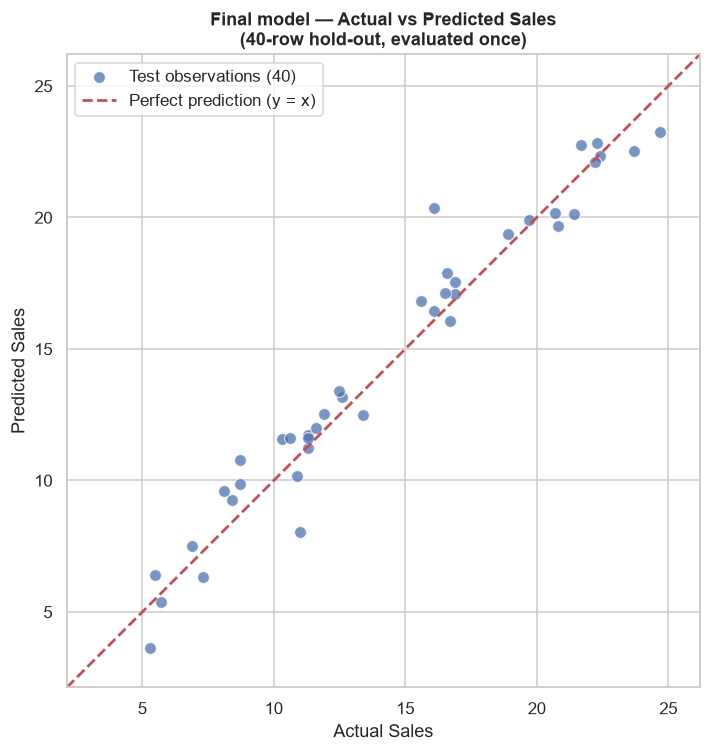

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 7))

lo = min(y_test.min(), y_pred.min()) - 1.5
hi = max(y_test.max(), y_pred.max()) + 1.5

ax.scatter(y_test, y_pred, s=60, alpha=0.75, color="#4C72B0", edgecolor="white", linewidth=0.7,
           label="Test observations (40)")
ax.plot([lo, hi], [lo, hi], color="#C44E52", linestyle="--", linewidth=1.8,
        label="Perfect prediction (y = x)")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_title("Final model — Actual vs Predicted Sales\n(40-row hold-out, evaluated once)")
ax.set_xlabel("Actual Sales")
ax.set_ylabel("Predicted Sales")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(VIZ_DIR / "16_final_actual_vs_predicted.png")
plt.show()

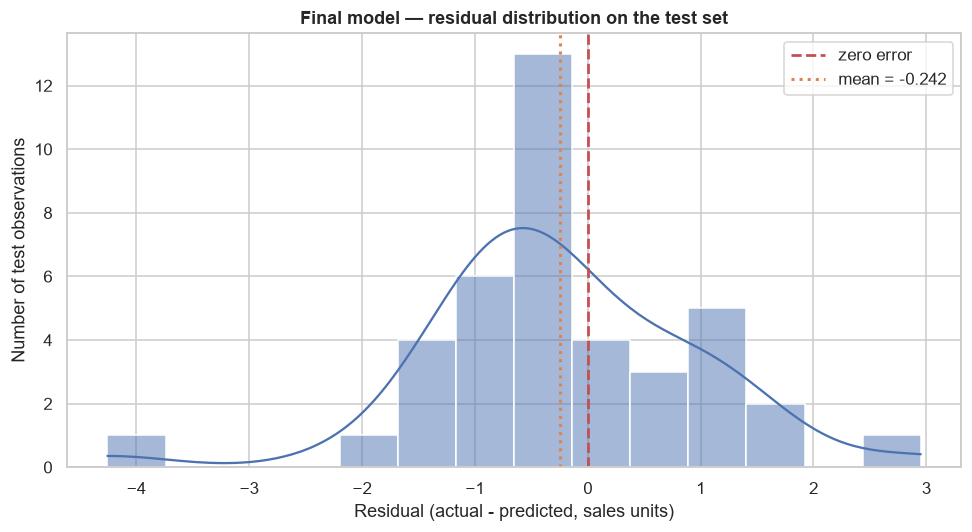

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(residuals, bins=14, kde=True, color="#4C72B0", ax=ax)
ax.axvline(0, color="#C44E52", linestyle="--", linewidth=1.8, label="zero error")
ax.axvline(residuals.mean(), color="#DD8452", linestyle=":", linewidth=2,
           label=f"mean = {residuals.mean():.3f}")
ax.set_title("Final model — residual distribution on the test set")
ax.set_xlabel("Residual (actual - predicted, sales units)")
ax.set_ylabel("Number of test observations")
ax.legend()

fig.tight_layout()
fig.savefig(VIZ_DIR / "17_final_residual_distribution.png")
plt.show()

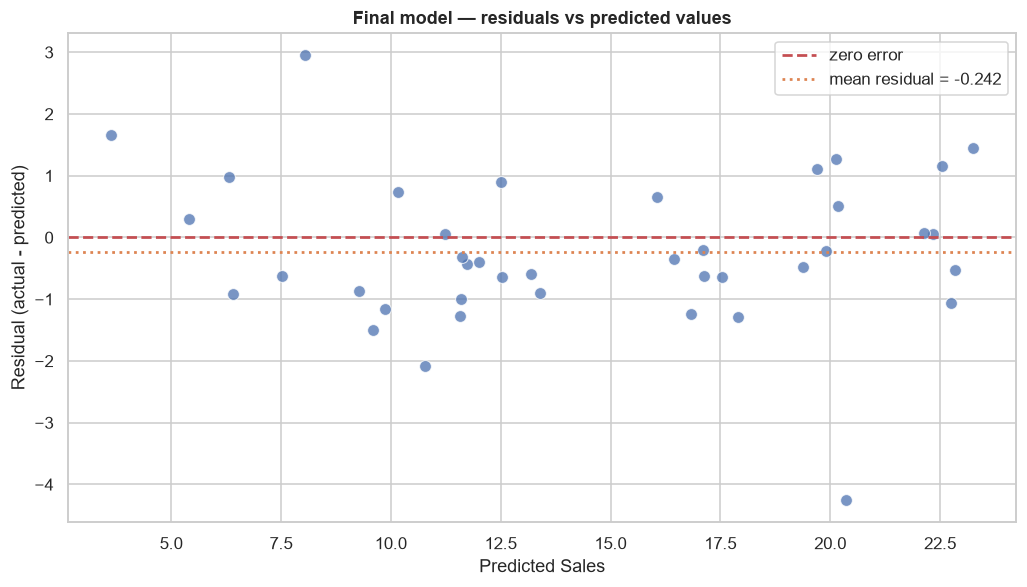

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(y_pred, residuals, s=60, alpha=0.75, color="#4C72B0", edgecolor="white", linewidth=0.7)
ax.axhline(0, color="#C44E52", linestyle="--", linewidth=1.8, label="zero error")
ax.axhline(residuals.mean(), color="#DD8452", linestyle=":", linewidth=1.8,
           label=f"mean residual = {residuals.mean():.3f}")
ax.set_title("Final model — residuals vs predicted values")
ax.set_xlabel("Predicted Sales")
ax.set_ylabel("Residual (actual - predicted)")
ax.legend()

fig.tight_layout()
fig.savefig(VIZ_DIR / "18_final_residuals_vs_predicted.png")
plt.show()

**Findings — with 40 observations, read cautiously.**

- **Largest under-prediction: +2.95** (row 66, actual 11.0 against a predicted 8.05).
- **Largest over-prediction: −4.26** (row 150, actual 16.1 against a predicted 20.36). This is also the
  largest absolute error.
- **Median absolute error 0.7970**, with a residual standard deviation of 1.21.
- **Mean residual −0.2422**, a mild over-prediction tendency. Small relative to the residual spread, and on
  40 rows not distinguishable from zero.
- Residuals are **mildly left-skewed** (skewness −0.3114), with 36 of 40 falling within ±1.5 sales units
  and four outside it — two of them clearly detached, at −4.26 and +2.95.

**Systematic patterns?** The residuals-versus-predicted plot shows no obvious funnel — the spread does not
visibly widen as predictions grow — and no clear curvature. The one mild pattern is that the largest errors
occur at both ends rather than in the middle, consistent with the narrower prediction range noted in section
7: the model pulls extreme cases slightly toward the centre. This is characteristic of tree ensembles, which
cannot extrapolate beyond the target values seen in training.

On the possible non-constant variance Phase 1 raised in the `TV` relationship: nothing in these residuals
confirms it, and 40 points cannot settle the question either way.

No causal claim is made or implied. The model captures association between advertising budgets and sales in
observational data; it cannot establish that changing a budget would change sales.

---
## 10. Prediction Error Analysis

Every test observation, with its inputs, prediction and error. Percentage error is `|residual| / actual`,
which is well-defined here because every actual `Sales` value in the test set is positive (minimum 5.3).

In [19]:
error_table = pd.DataFrame({
    "TV": X_test["TV"],
    "Radio": X_test["Radio"],
    "Newspaper": X_test["Newspaper"],
    "Actual Sales": y_test,
    "Predicted Sales": y_pred,
    "Residual": residuals,
    "Absolute Error": abs_errors,
    "Absolute % Error": abs_errors / y_test.to_numpy() * 100,
}, index=y_test.index)
error_table.index.name = "row"

assert len(error_table) == 40, "Error table must have one row per test observation."
assert (y_test > 0).all(), "Percentage error requires strictly positive actuals."

print(f"error table rows: {len(error_table)}  (original dataset indices preserved)")
error_table.sort_index()

error table rows: 40  (original dataset indices preserved)


,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error,Absolute % Error
row,,,,,,,,
9,199.8000,2.6000,21.2000,15.6000,16.8412,-1.2412,1.2412,7.9561
15,195.4000,47.7000,52.9000,22.4000,22.3402,0.0598,0.0598,0.2669
16,67.8000,36.6000,114.0000,12.5000,13.3993,-0.8993,0.8993,7.1944
18,69.2000,20.5000,18.3000,11.3000,11.6161,-0.3161,0.3161,2.7977
30,292.9000,28.3000,43.2000,21.4000,20.1272,1.2728,1.2728,5.9477
45,175.1000,22.5000,31.5000,16.1000,16.4473,-0.3473,0.3473,2.1569
55,198.9000,49.4000,60.0000,23.7000,22.5381,1.1619,1.1619,4.9026
56,7.3000,28.1000,41.4000,5.5000,6.4137,-0.9137,0.9137,16.6123
60,53.5000,2.0000,21.4000,8.1000,9.5933,-1.4933,1.4933,18.4353


In [20]:
by_error = error_table.sort_values("Absolute Error", ascending=False)
by_error.head(10)

,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error,Absolute % Error
row,,,,,,,,
150,280.7000,13.9000,37.0000,16.1000,20.3553,-4.2553,4.2553,26.4306
66,31.5000,24.6000,2.2000,11.0000,8.0498,2.9502,2.9502,26.8197
75,16.9000,43.7000,89.4000,8.7000,10.7761,-2.0761,2.0761,23.8637
78,5.4000,29.9000,9.4000,5.3000,3.6323,1.6677,1.6677,31.4666
60,53.5000,2.0000,21.4000,8.1000,9.5933,-1.4933,1.4933,18.4353
128,220.3000,49.0000,3.2000,24.7000,23.2570,1.4430,1.4430,5.8423
152,197.6000,23.3000,14.2000,16.6000,17.8955,-1.2955,1.2955,7.8043
186,139.5000,2.1000,26.6000,10.3000,11.5729,-1.2729,1.2729,12.3584
30,292.9000,28.3000,43.2000,21.4000,20.1272,1.2728,1.2728,5.9477


In [21]:
error_summary = pd.Series({
    "Mean absolute % error (MAPE)": error_table["Absolute % Error"].mean(),
    "Median absolute % error": error_table["Absolute % Error"].median(),
    "Largest absolute % error": error_table["Absolute % Error"].max(),
    "Observations with abs error > 2.0": int((abs_errors > 2).sum()),
    "Observations with abs error > 3.0": int((abs_errors > 3).sum()),
}).to_frame("Test set (40 rows)")
display(error_summary)

print("MAPE is reported for interpretability, with the usual caveat that it inflates for small actuals:")
print("row 78 has the largest percentage error (31.5%) from an absolute error of only 1.67 sales units,")
print("because its actual value of 5.3 is among the smallest in the test set.")

,Test set (40 rows)
Mean absolute % error (MAPE),8.1105
Median absolute % error,5.3606
Largest absolute % error,31.4666
Observations with abs error > 2.0,3.0000
Observations with abs error > 3.0,1.0000


MAPE is reported for interpretability, with the usual caveat that it inflates for small actuals:
row 78 has the largest percentage error (31.5%) from an absolute error of only 1.67 sales units,
because its actual value of 5.3 is among the smallest in the test set.


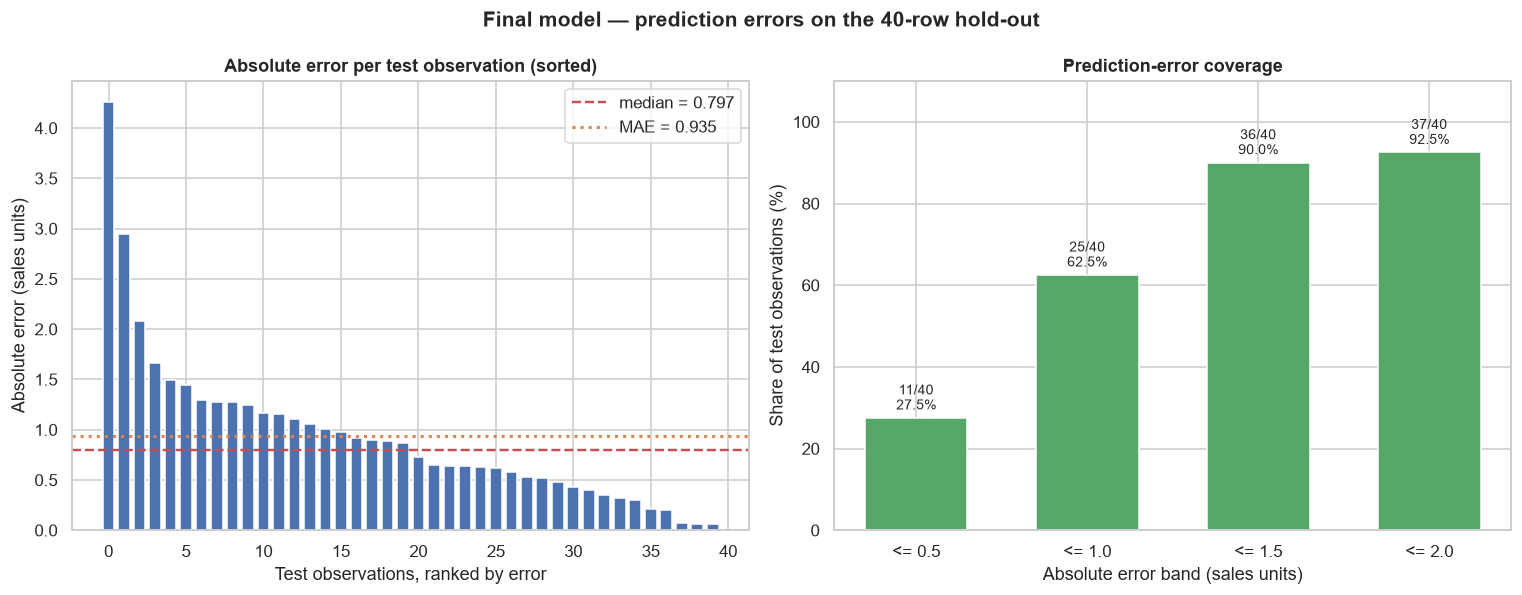

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sorted_err = by_error.reset_index()
axes[0].bar(range(len(sorted_err)), sorted_err["Absolute Error"], color="#4C72B0", width=0.75)
axes[0].axhline(np.median(abs_errors), color="#C44E52", linestyle="--", linewidth=1.6,
                label=f"median = {np.median(abs_errors):.3f}")
axes[0].axhline(final_metrics["MAE"], color="#DD8452", linestyle=":", linewidth=2,
                label=f"MAE = {final_metrics['MAE']:.3f}")
axes[0].set_title("Absolute error per test observation (sorted)")
axes[0].set_xlabel("Test observations, ranked by error")
axes[0].set_ylabel("Absolute error (sales units)")
axes[0].legend()

counts = [int((abs_errors <= b).sum()) for b in (0.5, 1.0, 1.5, 2.0)]
labels = ["<= 0.5", "<= 1.0", "<= 1.5", "<= 2.0"]
bars = axes[1].bar(labels, [c / len(abs_errors) * 100 for c in counts], color="#55A868", width=0.6)
axes[1].bar_label(bars, labels=[f"{c}/40\n{c / 40 * 100:.1f}%" for c in counts], padding=3, fontsize=9)
axes[1].set_title("Prediction-error coverage")
axes[1].set_xlabel("Absolute error band (sales units)")
axes[1].set_ylabel("Share of test observations (%)")
axes[1].set_ylim(0, 110)

fig.suptitle("Final model — prediction errors on the 40-row hold-out", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "19_final_prediction_errors.png")
plt.show()

In [23]:
# The Newspaper outlier Phase 1 flagged that fell in the test set (row 16). Reported, not acted on.
q1, q3 = df["Newspaper"].quantile([0.25, 0.75])
flagged = df.index[df["Newspaper"] > q3 + 1.5 * (q3 - q1)]
flagged_in_test = [i for i in flagged if i in y_test.index]

if flagged_in_test:
    view = error_table.loc[flagged_in_test].copy()
    view["Error rank (of 40)"] = [int(by_error.index.get_loc(i)) + 1 for i in flagged_in_test]
    display(view)
    for i in flagged_in_test:
        print(f"row {i}: absolute error {error_table.loc[i, 'Absolute Error']:.4f} "
              f"vs median {np.median(abs_errors):.4f}, rank "
              f"{int(by_error.index.get_loc(i)) + 1} of 40")
else:
    print("No flagged outlier fell in the test set.")

,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error,Absolute % Error,Error rank (of 40)
row,,,,,,,,,
16,67.8000,36.6000,114.0000,12.5000,13.3993,-0.8993,0.8993,7.1944,18


row 16: absolute error 0.8993 vs median 0.7970, rank 18 of 40


**Largest errors.** The two worst cases are the same observations Phase 3 struggled with, which is
consistent rather than surprising — they are unusual rows, not a defect introduced by tuning:

- **Row 150** (`TV` 280.7, `Radio` 13.9, `Newspaper` 37.0): actual 16.1, predicted 20.36. Heavy TV spend
  that did not translate into proportionate sales.
- **Row 66** (`TV` 31.5, `Radio` 24.6, `Newspaper` 2.2): actual 11.0, predicted 8.05. Minimal spend that
  outperformed its profile.

**The retained outlier.** Row 16 — the `Newspaper` = 114.0 observation Phase 1 flagged and Phases 2 and 4
deliberately kept — was predicted at 13.40 against an actual 12.5, an absolute error of **0.8993**. That is
marginally above the test set's median error of 0.7970 and ranks **18th of 40**, squarely in the middle of
the error distribution. Retaining it cost nothing measurable here, which is consistent with the reasoning
given in Phase 2 and re-tested in Phase 4 — though one observation in one split is weak evidence either way.

**3 of the 40 test observations** exceed an absolute error of 2.0, and **1** exceeds 3.0.

---
## 11. Persist Final Pipeline

The **complete** pipeline is saved — the fitted `ColumnTransformer` (carrying the `StandardScaler`'s learned
mean and scale) together with the fitted model. Saving only the estimator would produce an artefact that
silently mis-predicts, because it would receive raw budgets where it expects standardised ones.

Metadata is stored alongside the pipeline in the same file, so a consumer can check what it is loading
without needing this notebook or the dataset.

In [24]:
MODELS_DIR.mkdir(exist_ok=True)
ARTIFACT_PATH = MODELS_DIR / "final_sales_prediction_pipeline.joblib"

metadata = {
    "model_type": type(model).__name__,
    "hyperparameters": {k: v for k, v in FINAL_PARAMS.items()},
    "feature_names": list(dp.FEATURE_COLUMNS),
    "target_name": dp.TARGET_COLUMN,
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "random_state": RANDOM_STATE,
    "test_size": dp.TEST_SIZE,
    "dataset_sha256": dp.RAW_DATASET_SHA256,
    "dataset_filename": "advertising.csv",
    "sklearn_version": sklearn.__version__,
    "joblib_version": joblib.__version__,
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "selected_in": "Phase 4 — 5-fold CV on the 160 training rows",
    "cv_rmse": 1.2808,
    "cv_mae": 0.9393,
    "cv_r2": 0.9341,
    "test_metrics": {k: float(v) for k, v in final_metrics.items()},
    "training_feature_ranges": {
        c: [float(X_train[c].min()), float(X_train[c].max())] for c in dp.FEATURE_COLUMNS
    },
    "notes": (
        "Fitted on 160 of 200 rows of the ISLR Advertising dataset. Metrics are estimates from a small "
        "benchmark dataset and may not represent performance on future advertising campaigns."
    ),
}

# Predictions captured BEFORE saving, for the reload comparison in section 12.
predictions_before_save = final_pipeline.predict(X_test).copy()

joblib.dump({"pipeline": final_pipeline, "metadata": metadata}, ARTIFACT_PATH)

size_bytes = ARTIFACT_PATH.stat().st_size
artifact_sha256 = hashlib.sha256(ARTIFACT_PATH.read_bytes()).hexdigest()

print(f"artifact path   : {ARTIFACT_PATH.relative_to(PROJECT_DIR)}")
print(f"file size       : {size_bytes:,} bytes ({size_bytes / 1024:.1f} KiB)")
print(f"artifact sha-256: {artifact_sha256}")
print(f"model type      : {metadata['model_type']}")
print(f"features        : {metadata['feature_names']}")
print(f"target          : {metadata['target_name']}")
print(f"training rows   : {metadata['training_rows']}")
print(f"scikit-learn    : {metadata['sklearn_version']}")
print(f"python          : {metadata['python_version']}")
print(f"dataset sha-256 : {metadata['dataset_sha256']}")

artifact path   : models\final_sales_prediction_pipeline.joblib
file size       : 452,631 bytes (442.0 KiB)
artifact sha-256: 5391ee326cf03ebc1257597e3b10abefae5f967d683371b469787d7a7cc3d4a4
model type      : GradientBoostingRegressor
features        : ['TV', 'Radio', 'Newspaper']
target          : Sales
training rows   : 160
scikit-learn    : 1.9.1
python          : 3.13.0
dataset sha-256 : 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5


In [25]:
print(json.dumps(metadata, indent=2, default=str))

{
  "model_type": "GradientBoostingRegressor",
  "hyperparameters": {
    "n_estimators": 200,
    "learning_rate": 0.02,
    "max_depth": 4,
    "min_samples_leaf": 2,
    "subsample": 0.8,
    "random_state": 42
  },
  "feature_names": [
    "TV",
    "Radio",
    "Newspaper"
  ],
  "target_name": "Sales",
  "training_rows": 160,
  "test_rows": 40,
  "random_state": 42,
  "test_size": 0.2,
  "dataset_sha256": "137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5",
  "dataset_filename": "advertising.csv",
  "sklearn_version": "1.9.1",
  "joblib_version": "1.6.0",
  "python_version": "3.13.0",
  "pandas_version": "3.0.6",
  "numpy_version": "2.5.3",
  "selected_in": "Phase 4 \u2014 5-fold CV on the 160 training rows",
  "cv_rmse": 1.2808,
  "cv_mae": 0.9393,
  "cv_r2": 0.9341,
  "test_metrics": {
    "MAE": 0.9354088356261709,
    "MSE": 1.4818727495521902,
    "RMSE": 1.2173219580506178,
    "R2": 0.9520446602369433
  },
  "training_feature_ranges": {
    "TV": [
      0.7

---
## 12. Reload and Validate Artifact

Two checks. First, reload in this process and confirm the predictions are identical. Second — the check that
actually matters — reload in a **completely fresh Python process** that has no access to this notebook's
state, and confirm it produces the same numbers.

In [26]:
reloaded = joblib.load(ARTIFACT_PATH)
reloaded_pipeline = reloaded["pipeline"]
reloaded_metadata = reloaded["metadata"]

predictions_after_reload = reloaded_pipeline.predict(X_test)

identical = np.array_equal(predictions_before_save, predictions_after_reload)
max_diff = float(np.abs(predictions_before_save - predictions_after_reload).max())

print(f"predictions bit-identical after reload : {identical}")
print(f"maximum absolute difference            : {max_diff:.3e}")
print(f"metadata survived the round trip       : {reloaded_metadata['model_type'] == metadata['model_type']}")

assert identical, "Reloaded pipeline does not reproduce the pre-save predictions."

predictions bit-identical after reload : True
maximum absolute difference            : 0.000e+00
metadata survived the round trip       : True


In [27]:
# A genuinely fresh process: no imports, no variables and no fitted objects from this notebook.
probe = f'''
import json, sys
import numpy as np, pandas as pd, joblib

bundle = joblib.load(r"{ARTIFACT_PATH}")
pipeline = bundle["pipeline"]

X = pd.read_csv(r"{dp.default_dataset_path()}")[["TV", "Radio", "Newspaper"]]
from sklearn.model_selection import train_test_split
_, X_test = train_test_split(X, test_size=0.2, random_state=42, shuffle=True)

preds = pipeline.predict(X_test)
print(json.dumps({{"n": len(preds), "preds": preds.tolist()}}))
'''

completed = subprocess.run([sys.executable, "-c", probe], capture_output=True, text=True, timeout=300)
print("fresh process exit code:", completed.returncode)
if completed.returncode != 0:
    print(completed.stderr[-2000:])

payload = json.loads(completed.stdout.strip().splitlines()[-1])
fresh_preds = np.array(payload["preds"])

fresh_identical = np.array_equal(fresh_preds, predictions_before_save)
print(f"predictions returned          : {payload['n']}")
print(f"bit-identical to pre-save     : {fresh_identical}")
print(f"max absolute difference       : {np.abs(fresh_preds - predictions_before_save).max():.3e}")

assert completed.returncode == 0, "The fresh-process reload failed."
assert fresh_identical, "A fresh process produced different predictions from the saved artefact."
print("\nThe artefact is usable for prediction in a clean process, without retraining and without this notebook.")

fresh process exit code: 0
predictions returned          : 40
bit-identical to pre-save     : True
max absolute difference       : 0.000e+00

The artefact is usable for prediction in a clean process, without retraining and without this notebook.


**Result.** The persisted pipeline reproduces the pre-save predictions **bit-identically**, both on reload in
this process and in a fresh interpreter that loads only the artefact and the raw feature columns. The
artefact carries its own preprocessing, so no part of the pipeline has to be reconstructed by the consumer.

---
## 13. Prediction API Smoke Tests

[`src/predict.py`](../src/predict.py) is the interface later phases will use. It loads the artefact, validates
inputs and returns a prediction; it never trains, never writes to the artefact and never needs the dataset.

In [28]:
import predict as predict_api

# The module caches by path; clear it so this run reflects the artefact just written.
predict_api._load_cached.cache_clear()

api_rows = []
for idx in list(X_test.index[:5]) + list(by_error.index[:2]):
    row = X_test.loc[idx]
    api_value = predict_api.predict_sales(row["TV"], row["Radio"], row["Newspaper"])
    pipeline_value = float(predictions_before_save[list(X_test.index).index(idx)])
    api_rows.append({
        "row": idx,
        "TV": row["TV"], "Radio": row["Radio"], "Newspaper": row["Newspaper"],
        "predict_sales()": api_value,
        "pipeline.predict()": pipeline_value,
        "identical": api_value == pipeline_value,
    })

api_check = pd.DataFrame(api_rows).set_index("row")
display(api_check)

assert api_check["identical"].all(), "predict_sales() disagrees with the fitted pipeline."
print("The prediction API reproduces the pipeline's output exactly on every tested row.")

,TV,Radio,Newspaper,predict_sales(),pipeline.predict(),identical
row,,,,,,
95,163.3000,31.6000,52.9000,17.0967,17.0967,True
15,195.4000,47.7000,52.9000,22.3402,22.3402,True
30,292.9000,28.3000,43.2000,20.1272,20.1272,True
158,11.7000,36.9000,45.2000,6.3238,6.3238,True
128,220.3000,49.0000,3.2000,23.2570,23.2570,True
150,280.7000,13.9000,37.0000,20.3553,20.3553,True
66,31.5000,24.6000,2.2000,8.0498,8.0498,True


The prediction API reproduces the pipeline's output exactly on every tested row.


In [29]:
# Representative budget combinations spanning the training ranges.
# These are ILLUSTRATIVE inputs, not rows from the dataset and not real observed campaigns.
smoke_rows = []
for label, tv, radio, newspaper in predict_api.SMOKE_TEST_CASES:
    smoke_rows.append({
        "Scenario": label,
        "TV": tv, "Radio": radio, "Newspaper": newspaper,
        "Predicted Sales": predict_api.predict_sales(tv, radio, newspaper),
    })

smoke = pd.DataFrame(smoke_rows)
display(smoke)

ranges = predict_api.training_ranges()
print("training ranges the model actually saw:")
for feature, (low, high) in ranges.items():
    print(f"  {feature:10s} {low:7.2f} to {high:7.2f}")
print()
print("These scenarios are hypothetical budget combinations chosen to span those ranges. They do NOT")
print("correspond to real historical observations, and the predictions are not claims about what such")
print("campaigns would actually achieve.")

,Scenario,TV,Radio,Newspaper,Predicted Sales
0,low spend across all platforms,10.0000,5.0000,5.0000,5.2750
1,medium spend across all platforms,150.0000,25.0000,30.0000,14.0096
2,"high TV, low other",290.0000,5.0000,5.0000,17.4267
3,"high Radio, low other",10.0000,48.0000,5.0000,5.7700
4,"high Newspaper, low other",10.0000,5.0000,110.0000,7.0281
5,high spend across all platforms,290.0000,48.0000,110.0000,26.2111


training ranges the model actually saw:
  TV            0.70 to  296.40
  Radio         0.00 to   49.60
  Newspaper     0.30 to  100.90

These scenarios are hypothetical budget combinations chosen to span those ranges. They do NOT
correspond to real historical observations, and the predictions are not claims about what such
campaigns would actually achieve.


In [30]:
# Input validation: each case must be rejected with a clear error.
def expect_rejected(label, fn):
    try:
        fn()
    except (TypeError, ValueError) as exc:
        print(f"[rejected] {label}\n           -> {type(exc).__name__}: {str(exc).splitlines()[0]}")
        return True
    print(f"[NOT REJECTED] {label}  <- validation gap")
    return False


checks = [
    expect_rejected("missing value (None)", lambda: predict_api.predict_sales(None, 25.0, 30.0)),
    expect_rejected("missing value (NaN)", lambda: predict_api.predict_sales(float("nan"), 25.0, 30.0)),
    expect_rejected("non-numeric string", lambda: predict_api.predict_sales("abc", 25.0, 30.0)),
    expect_rejected("empty string", lambda: predict_api.predict_sales("", 25.0, 30.0)),
    expect_rejected("boolean", lambda: predict_api.predict_sales(True, 25.0, 30.0)),
    expect_rejected("infinity", lambda: predict_api.predict_sales(float("inf"), 25.0, 30.0)),
    expect_rejected("negative budget", lambda: predict_api.predict_sales(-10.0, 25.0, 30.0)),
    expect_rejected("None in Radio", lambda: predict_api.predict_sales(150.0, None, 30.0)),
    expect_rejected("NaN in Newspaper", lambda: predict_api.predict_sales(150.0, 25.0, float("nan"))),
    expect_rejected("batch missing a column",
                    lambda: predict_api.predict_batch(pd.DataFrame([{"TV": 1.0, "Radio": 2.0}]))),
]

print(f"\nvalidation cases rejected as expected: {sum(checks)} / {len(checks)}")
assert all(checks), "A validation case was not rejected."

[rejected] missing value (None)
           -> ValueError: TV is required but was None. Provide a numeric advertising budget.
[rejected] missing value (NaN)
           -> ValueError: TV is missing (NaN). This model does not impute missing budgets — supply a value or handle the gap before calling.
[rejected] non-numeric string
           -> TypeError: TV must be numeric, got the non-numeric string 'abc'.
[rejected] empty string
           -> ValueError: TV is required but was an empty string.
[rejected] boolean
           -> TypeError: TV must be a number, got a boolean (True).
[rejected] infinity
           -> ValueError: TV must be finite, got inf.
[rejected] negative budget
           -> ValueError: TV must be zero or positive, got -10.0. Budgets cannot be negative.
[rejected] None in Radio
           -> ValueError: Radio is required but was None. Provide a numeric advertising budget.
[rejected] NaN in Newspaper
           -> ValueError: Newspaper is missing (NaN). This model does not

In [31]:
# Valid inputs that should be accepted, including numeric strings and integer zero.
accepted = pd.DataFrame([
    {"input style": "floats", "value": predict_api.predict_sales(150.0, 25.0, 30.0)},
    {"input style": "integers", "value": predict_api.predict_sales(150, 25, 30)},
    {"input style": "numeric strings", "value": predict_api.predict_sales("150", "25", "30")},
    {"input style": "zero budgets", "value": predict_api.predict_sales(0, 0, 0)},
])
display(accepted)

same = np.isclose(accepted.loc[0, "value"], accepted.loc[1, "value"]) and \
       np.isclose(accepted.loc[0, "value"], accepted.loc[2, "value"])
print("floats, integers and numeric strings give the same prediction:", bool(same))
assert same

,input style,value
0,floats,14.0096
1,integers,14.0096
2,numeric strings,14.0096
3,zero budgets,2.9991


floats, integers and numeric strings give the same prediction: True


In [32]:
# Batch interface and the CLI, exercised end to end.
batch_out = predict_api.predict_batch(X_test.head(5))
display(batch_out)

batch_matches = np.allclose(batch_out["Predicted Sales"].to_numpy(), predictions_before_save[:5])
print("predict_batch matches the fitted pipeline:", bool(batch_matches))
assert batch_matches

cli = subprocess.run(
    [sys.executable, str(SRC_DIR / "predict.py"), "--tv", "150", "--radio", "25", "--newspaper", "30"],
    capture_output=True, text=True, timeout=300,
)
print(f"\nCLI exit code: {cli.returncode}")
print(f"CLI output   : {cli.stdout.strip()}")
assert cli.returncode == 0

cli_bad = subprocess.run(
    [sys.executable, str(SRC_DIR / "predict.py"), "--tv", "abc", "--radio", "25", "--newspaper", "30"],
    capture_output=True, text=True, timeout=300,
)
print(f"\nCLI with bad input exit code: {cli_bad.returncode} (expected 1)")
print(f"CLI stderr: {cli_bad.stderr.strip()}")
assert cli_bad.returncode == 1

,TV,Radio,Newspaper,Predicted Sales
95,163.3000,31.6000,52.9000,17.0967
15,195.4000,47.7000,52.9000,22.3402
30,292.9000,28.3000,43.2000,20.1272
158,11.7000,36.9000,45.2000,6.3238
128,220.3000,49.0000,3.2000,23.2570


predict_batch matches the fitted pipeline: True



CLI exit code: 0
CLI output   : 14.0096



CLI with bad input exit code: 1 (expected 1)
CLI stderr: error: TV must be numeric, got the non-numeric string 'abc'.


**Result.** The API reproduces the pipeline exactly, accepts floats, integers and numeric strings
identically, and rejects all ten invalid-input cases with specific errors. The CLI returns a prediction on
valid input and exits non-zero with a clear message on invalid input.

The smoke-test scenarios are illustrative budget combinations chosen to span the training ranges. They are
**not** rows from the dataset and do not describe real campaigns; the predictions attached to them are what
the model outputs for those hypothetical inputs, nothing more.

---
## 14. Data and Artifact Integrity

In [33]:
checksum = dp.verify_raw_dataset_integrity()
dataset_path = dp.default_dataset_path()

print("RAW DATASET")
print(f"  file     : {dataset_path.relative_to(PROJECT_DIR)}")
print(f"  size     : {dataset_path.stat().st_size} bytes")
print(f"  sha-256  : {checksum}")
print(f"  expected : {dp.RAW_DATASET_SHA256}")
print(f"  unchanged: {checksum == dp.RAW_DATASET_SHA256}")

assert checksum == dp.RAW_DATASET_SHA256, "RAW DATASET CHECKSUM CHANGED. STOP."

print()
print("ARTIFACT")
print(f"  file     : {ARTIFACT_PATH.relative_to(PROJECT_DIR)}")
print(f"  size     : {ARTIFACT_PATH.stat().st_size:,} bytes")
print(f"  sha-256  : {hashlib.sha256(ARTIFACT_PATH.read_bytes()).hexdigest()}")
print(f"  loadable : {ARTIFACT_PATH.is_file()}")

print()
print("Phase 5 read the dataset only; nothing was written to dataset/.")

RAW DATASET
  file     : dataset\advertising.csv
  size     : 4062 bytes
  sha-256  : 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5
  expected : 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5
  unchanged: True

ARTIFACT
  file     : models\final_sales_prediction_pipeline.joblib
  size     : 452,631 bytes
  sha-256  : 5391ee326cf03ebc1257597e3b10abefae5f967d683371b469787d7a7cc3d4a4
  loadable : True

Phase 5 read the dataset only; nothing was written to dataset/.


---
## 15. Reproducibility Checks

In [34]:
# Refitting the locked configuration must reproduce the final metrics exactly.
refit_pipeline = Pipeline([
    ("preprocessor", dp.build_preprocessor()),
    ("model", GradientBoostingRegressor(**FINAL_PARAMS)),
])
refit_pipeline.fit(X_train, y_train)
refit_pred = refit_pipeline.predict(X_test)

refit_mse = mean_squared_error(y_test, refit_pred)
refit_metrics = {
    "MAE": mean_absolute_error(y_test, refit_pred),
    "MSE": refit_mse,
    "RMSE": float(np.sqrt(refit_mse)),
    "R2": r2_score(y_test, refit_pred),
}

repro = pd.DataFrame([
    {"Metric": k, "First fit": final_metrics[k], "Refit": refit_metrics[k],
     "Identical": final_metrics[k] == refit_metrics[k]}
    for k in final_metrics
])
display(repro)

print("predictions bit-identical on refit:", bool(np.array_equal(refit_pred, predictions_before_save)))
assert repro["Identical"].all(), "Final metrics did not reproduce on refit."

,Metric,First fit,Refit,Identical
0,MAE,0.9354,0.9354,True
1,MSE,1.4819,1.4819,True
2,RMSE,1.2173,1.2173,True
3,R2,0.9520,0.9520,True


predictions bit-identical on refit: True


In [35]:
final_checks = pd.DataFrame([
    {"Check": "200 dataset rows", "Passed": len(df) == 200},
    {"Check": "160 training rows / 40 test rows",
     "Passed": len(X_train) == 160 and len(X_test) == 40},
    {"Check": "random_state = 42", "Passed": split.random_state == 42},
    {"Check": "test fingerprint matches Phase 4", "Passed": test_fp == PHASE4_TEST_FINGERPRINT},
    {"Check": "scaler fitted on training rows only",
     "Passed": int(scaler.n_samples_seen_) == 160 and not fitted_on_full},
    {"Check": "40 predictions, all finite",
     "Passed": len(y_pred) == 40 and bool(np.isfinite(y_pred).all())},
    {"Check": "no NaN predictions", "Passed": not bool(np.isnan(y_pred).any())},
    {"Check": "error table has 40 rows", "Passed": len(error_table) == 40},
    {"Check": "hyperparameters match the Phase 4 selection",
     "Passed": {k: v for k, v in FINAL_PARAMS.items() if k != "random_state"} ==
               {"n_estimators": 200, "learning_rate": 0.02, "max_depth": 4,
                "min_samples_leaf": 2, "subsample": 0.8}},
    {"Check": "artifact saved", "Passed": ARTIFACT_PATH.is_file()},
    {"Check": "artifact reloads bit-identically", "Passed": identical},
    {"Check": "fresh process reproduces predictions", "Passed": fresh_identical},
    {"Check": "prediction API matches the pipeline", "Passed": bool(api_check["identical"].all())},
    {"Check": "raw dataset checksum unchanged", "Passed": checksum == dp.RAW_DATASET_SHA256},
    {"Check": "final metrics reproduce on refit", "Passed": bool(repro["Identical"].all())},
])
display(final_checks)

print(f"passed {int(final_checks['Passed'].sum())} / {len(final_checks)} checks")
assert final_checks["Passed"].all(), "A Phase 5 validation check failed."

,Check,Passed
0,200 dataset rows,True
1,160 training rows / 40 test rows,True
2,random_state = 42,True
3,test fingerprint matches Phase 4,True
4,scaler fitted on training rows only,True
5,"40 predictions, all finite",True
6,no NaN predictions,True
7,error table has 40 rows,True
8,hyperparameters match the Phase 4 selection,True
9,artifact saved,True


passed 15 / 15 checks


In [36]:
print("Environment for this run:")
print(f"  python       {platform.python_version()}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  joblib       {joblib.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  numpy        {np.__version__}")
print()
print("Seeds: random_state=42 for the split and for the GradientBoostingRegressor.")
print("GradientBoostingRegressor with subsample<1.0 is stochastic; random_state fixes its draws, so the")
print("fitted model and every metric above are deterministic given these library versions.")

Environment for this run:
  python       3.13.0
  scikit-learn 1.9.1
  joblib       1.6.0
  pandas       3.0.6
  numpy        2.5.3

Seeds: random_state=42 for the split and for the GradientBoostingRegressor.
GradientBoostingRegressor with subsample<1.0 is stochastic; random_state fixes its draws, so the
fitted model and every metric above are deterministic given these library versions.


---
## 16. Phase 5 Conclusions

### The final result

| | |
|---|---|
| **Final model** | `GradientBoostingRegressor(n_estimators=200, learning_rate=0.02, max_depth=4, min_samples_leaf=2, subsample=0.8, random_state=42)` |
| **Preprocessing** | Phase 2 `ColumnTransformer` + `StandardScaler`, fitted on the 160 training rows |
| **Selected by** | Phase 4 5-fold cross-validation on the training set — **not** by anything in this notebook |
| **Phase 4 CV** | RMSE 1.2808 ± 0.1936 · MAE 0.9393 · R² 0.9341 *(training set)* |
| **Phase 5 TEST** | **RMSE 1.2173 · MAE 0.9354 · MSE 1.4819 · R² 0.9520** *(40 held-out rows, evaluated once)* |
| **vs baseline** | 78.4% lower RMSE, 81.0% lower MAE |
| **Error profile** | median absolute error 0.797; 62.5% of predictions within ±1.0 sales units, 90.0% within ±1.5, 92.5% within ±2.0; worst miss 4.26 |
| **Bias** | −0.2422 (mild over-prediction) |
| **Artifact** | `models/final_sales_prediction_pipeline.joblib` |
| **API** | `src/predict.py` — `predict_sales(tv, radio, newspaper)` |
| **Raw data** | checksum unchanged |

### What can honestly be claimed

The model explains most of the variation in sales on data it had never seen, missing by about 0.94 sales
units on average, and it beats a naive mean predictor by roughly 78%. The relationship between advertising
budgets and sales in this dataset is strong and largely captured.

### What cannot

- **This is not a perfect model.** It missed one test observation by 4.26 sales units, 3 of 40 by more than
  2.0, and 4 of 40 by more than 1.5.
- **The metrics are small-sample estimates.** 40 test rows out of 200. The confidence interval around any of
  these figures is wide, and a different 40-row split would give noticeably different numbers — as this
  project demonstrated repeatedly: the same hold-out ranked Gradient Boosting above Random Forest, which
  cross-validation then reversed; and it ranks the untuned configuration above the tuned one, which
  cross-validation also reversed.
- **These figures do not transfer to future advertising campaigns.** The data is a 200-row benchmark of
  unknown provenance, with no time dimension, no market or audience information, and no record of the units
  involved. Nothing here supports extrapolating to campaigns, products or markets unlike those in the
  dataset.
- **No causal claim.** The model captures association in observational data. It cannot say what would happen
  to sales if a budget were changed.

### Honest note on the tuned-vs-untuned comparison

The tuned model scored 1.2173 on the hold-out where the untuned Phase 3 configuration scored 1.1451. The
tuned model was nonetheless reported as final, because it was selected in advance by cross-validation and
switching now would be selecting on the test set. Phase 4 showed these configurations are statistically
indistinguishable on this data, so neither figure establishes one as better. Following the pre-registered
rule costs 0.07 RMSE units of reported performance and buys a result that means what it says.

### Handover to the next phase

The dashboard phase should consume `models/final_sales_prediction_pipeline.joblib` through
`src/predict.py`. It must not refit, re-tune, or re-evaluate on the test set — the hold-out has now been
used, and any further measurement against it would no longer be an unbiased estimate.